# NERF — Benchmarking cyber-threat-intel NER models on DNRTI

A single, self-contained notebook — runs the same in **Google Colab** or **locally** — benchmarking three NER models on the DNRTI dataset:

- **SecureBERT-NER** — `CyberPeace-Institute/SecureBERT-NER` (RoBERTa, APTNER taxonomy)
- **CyNER-base** — `AI4Sec/cyner-xlm-roberta-base` (XLM-RoBERTa, 5 classes)
- **SecureBERT2.0-NER** — `cisco-ai/SecureBERT2.0-NER` (ModernBERT, 5 classes)

**Pipeline**
1. Install deps and configure paths.
2. Upload + parse DNRTI (CoNLL BIO).
3. Align every taxonomy onto a common class set.
4. Run **every** model over the split (full split by default).
5. Score with seqeval (per-class + overall), a fair **shared-class** view, and the four **matching schemes** (strict / exact / partial / type) via `nervaluate`.
6. Measure latency + model footprint.
7. Save JSON, plot the chart, and bundle everything for one-click download.
8. Model-selection writeup.

> All three are standard HuggingFace token-classification models — no CyNER package or C++ toolchain needed.

### Note — CyNER-large was intentionally skipped

CyNER's paper reports **xlm-roberta-large** as its best model, so I tried to include it. But its **trained weights are not publicly available**:

- the HuggingFace repo `AI4Sec/cyner-xlm-roberta-large` contains only `config.json` / `parameter.json` — **no `model.safetensors` / `pytorch_model.bin`**;
- the CyNER GitHub repo ships only the package source + the MITRE dataset, with **no weights and no download link**.

Loading the config alone yields a randomly-initialised model (0.0 F1), which is worse than nothing. To use CyNER-large you'd have to **fine-tune it yourself** on `dataset/mitre` — out of scope here. I therefore **skipped CyNER-large** and, in its place, added **SecureBERT2.0-NER** (Cisco's newer ModernBERT model, which shares CyNER's 5-class taxonomy) as a third, genuinely-loadable comparator.

## 0. Setup — install dependencies

In [ ]:
import sys, subprocess

IN_COLAB = "google.colab" in sys.modules
print("Environment:", "Google Colab" if IN_COLAB else "Local")

def pip(*args):
    subprocess.run([sys.executable, "-m", "pip", "install", *args])

# transformers must be recent enough for ModernBERT (SecureBERT2.0-NER)
pip("-q", "-U", "transformers")
pip("-q", "torch", "seqeval", "nervaluate", "pandas", "matplotlib", "numpy", "psutil")
print("Ready.")

Environment: Google Colab
Ready.


In [ ]:
import os, time, json, random, statistics, zipfile, shutil
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from transformers import pipeline
from seqeval.metrics import classification_report, precision_score, recall_score, f1_score
from seqeval.metrics.sequence_labeling import get_entities

## 1. Config

Model ids, the DNRTI split, and (in Colab) where results are written. `SUBSET_SIZE = None` evaluates the **entire** split.

In [ ]:
# --- Google Drive (Colab): write results back to your synced NERF folder ---
USE_DRIVE = True                              # set False to keep results under /content
DRIVE_NERF = "/content/drive/MyDrive/NERF"    # My Drive shortcut to your NERF folder

if IN_COLAB and USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")

if IN_COLAB and USE_DRIVE:
    RESULTS_DIR = Path(DRIVE_NERF) / "benchmark" / "results"
elif IN_COLAB:
    RESULTS_DIR = Path("/content/results")
else:
    RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# DNRTI: uploaded in Colab (-> /content/dnrti), or read from the benchmark folder locally
DATA_DIR = Path("/content/dnrti") if IN_COLAB else Path(".")
DNRTI_FILE = "test.txt"                        # which split to evaluate (matched by stem)

# Model registry: (display name, HF model id, mapping scheme)
# CyNER-base and SecureBERT2.0-NER share the same 5-class label set -> scheme "fiveclass".
# (CyNER-large omitted: no public weights — see the note at the top.)
MODEL_SPECS = [
    ("SecureBERT-NER",    "CyberPeace-Institute/SecureBERT-NER", "securebert"),
    ("CyNER-base",        "AI4Sec/cyner-xlm-roberta-base",       "fiveclass"),
    ("SecureBERT2.0-NER", "cisco-ai/SecureBERT2.0-NER",          "fiveclass"),
]

SUBSET_SIZE = None                             # None = full split; int = sample that many
RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)

print("RESULTS_DIR:", RESULTS_DIR)
print("Models:", [n for n, _, _ in MODEL_SPECS])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
RESULTS_DIR: /content/drive/MyDrive/NERF/benchmark/results
Models: ['SecureBERT-NER', 'CyNER-base', 'SecureBERT2.0-NER']


## 2. Label mapping

Aligns every taxonomy onto the common classes (per the assignment's mapping table). DNRTI's `Purp`/`Features` have no equivalent and are excluded.

- **SecureBERT-NER** uses the fine-grained APTNER tags -> `securebert` scheme.
- **CyNER-base** and **SecureBERT2.0-NER** share the same 5 coarse classes (Organization / System / Vulnerability / Malware / Indicator, no Time/Area) -> `fiveclass` scheme.

In [ ]:
COMMON_CLASSES = ["Organization", "System", "Vulnerability", "Malware", "Indicator", "Time", "Area"]

SECUREBERT_TO_COMMON = {
    "APT": "Organization", "SECTEAM": "Organization", "IDTY": "Organization",
    "ACT": "System", "OS": "System", "TOOL": "System",
    "VULID": "Vulnerability", "VULNAME": "Vulnerability",
    "MAL": "Malware",
    "FILE": "Indicator", "DOM": "Indicator", "ENCR": "Indicator", "IP": "Indicator",
    "URL": "Indicator", "MD5": "Indicator", "PROT": "Indicator", "EMAIL": "Indicator",
    "SHA1": "Indicator", "SHA2": "Indicator",
    "TIME": "Time", "LOC": "Area",
}
DNRTI_TO_COMMON = {
    "HackOrg": "Organization", "SecTeam": "Organization", "Idus": "Organization", "Org": "Organization",
    "OffAct": "System", "Way": "System",
    "Exp": "Vulnerability", "Tool": "Malware", "SamFile": "Indicator",
    "Time": "Time", "Area": "Area",
    "Purp": None, "Features": None,
}
# CyNER-base and SecureBERT2.0-NER both emit exactly these 5 classes (identity map).
FIVECLASS_TO_COMMON = {c: c for c in ["Organization", "System", "Vulnerability", "Malware", "Indicator"]}

def strip_bio(tag):
    if tag == "O" or "-" not in tag:
        return ("O", "") if tag == "O" else ("", tag)
    p, b = tag.split("-", 1)
    return p, b

def map_bio_to_common(tag, scheme):
    if not tag or tag == "O":
        return "O"
    prefix, base = strip_bio(tag)
    if scheme == "securebert":
        common = SECUREBERT_TO_COMMON.get(base)
    elif scheme == "fiveclass":
        common = FIVECLASS_TO_COMMON.get(base)
    else:  # dnrti
        common = DNRTI_TO_COMMON.get(base)
    return f"{prefix}-{common}" if (common and prefix in ("B", "I")) else "O"

print("Common classes:", COMMON_CLASSES)

Common classes: ['Organization', 'System', 'Vulnerability', 'Malware', 'Indicator', 'Time', 'Area']


## 3. Load DNRTI

In Colab an **upload box** appears — upload your DNRTI `.rar` (or `.zip`, or the raw `.txt` files: `test` / `train` / `valid`). Locally, place the files in this benchmark folder. Parses CoNLL BIO (`token TAG` per line, blank line between sentences).

In [ ]:
def load_conll(path):
    """Parse CoNLL BIO: 'token TAG' per line, blank line = sentence break -> [(tokens, tags)]."""
    sentences, tokens, tags = [], [], []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.rstrip("\n")
            if not line.strip():
                if tokens:
                    sentences.append((tokens, tags)); tokens, tags = [], []
                continue
            parts = line.split()
            tokens.append(parts[0]); tags.append(parts[-1])
    if tokens:
        sentences.append((tokens, tags))
    return sentences

# --- Get the DNRTI files: upload box in Colab, local folder otherwise ---
if IN_COLAB:
    from google.colab import files
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    print("Upload your DNRTI archive (.rar / .zip) or the .txt files (test / train / valid):")
    for fname, blob in files.upload().items():
        dest = DATA_DIR / fname
        dest.write_bytes(blob)
        low = fname.lower()
        if low.endswith(".zip"):
            with zipfile.ZipFile(dest) as z:
                z.extractall(DATA_DIR)
        elif low.endswith(".rar"):
            if subprocess.run(["which", "unrar"], capture_output=True).returncode != 0:
                subprocess.run(["apt-get", "-qq", "install", "-y", "unrar"])
            r = subprocess.run(["unrar", "x", "-o+", str(dest), str(DATA_DIR) + "/"])
            if r.returncode != 0:
                subprocess.run(["apt-get", "-qq", "install", "-y", "p7zip-full", "p7zip-rar"])
                subprocess.run(["7z", "x", "-y", str(dest), "-o" + str(DATA_DIR)])
    print("\nFiles under", DATA_DIR, ":")
    for p in sorted(DATA_DIR.rglob("*")):
        if p.is_file():
            print("  ", p.relative_to(DATA_DIR), f"({p.stat().st_size // 1024} KB)")

# --- Locate the chosen split (recursive; archive may nest a folder; ext may be missing) ---
stem = Path(DNRTI_FILE).stem
matches = [p for p in Path(DATA_DIR).rglob("*") if p.is_file() and p.stem == stem]
assert matches, (f"'{DNRTI_FILE}' (stem '{stem}') not found under {DATA_DIR}. "
                 f"Found: {[p.name for p in Path(DATA_DIR).rglob('*') if p.is_file()]}")
data_path = matches[0]
sentences = load_conll(data_path)
print(f"\nLoaded {len(sentences)} sentences from {data_path}")

gold_tag_counts = Counter(t for _, tags in sentences for t in tags)
print("Raw DNRTI tags:", dict(gold_tag_counts))

Upload your DNRTI archive (.rar / .zip) or the .txt files (test / train / valid):


Saving DNRTI.rar to DNRTI (2).rar

Files under /content/dnrti :
   DNRTI (1).rar (280 KB)
   DNRTI (2).rar (280 KB)
   DNRTI.rar (280 KB)
   test.txt (180 KB)
   train.txt (1437 KB)
   valid.txt (178 KB)

Loaded 664 sentences from /content/dnrti/test.txt
Raw DNRTI tags: {'B-SecTeam': 152, 'O': 14126, 'B-HackOrg': 369, 'B-Area': 216, 'I-HackOrg': 133, 'B-Tool': 315, 'I-Tool': 161, 'I-SecTeam': 56, 'B-SamFile': 248, 'I-SamFile': 95, 'B-Purp': 115, 'B-Org': 137, 'I-Org': 101, 'B-Idus': 127, 'I-Idus': 38, 'I-Purp': 145, 'B-Time': 167, 'B-Exp': 132, 'B-OffAct': 150, 'B-Way': 100, 'I-Way': 89, 'I-Area': 52, 'I-Time': 101, 'I-OffAct': 91, 'I-Exp': 49, 'B-Features': 116, 'I-Features': 151}


## 4. Subset

`SUBSET_SIZE = None` (default) evaluates the whole split, keeping sentences that contain at least one entity. Set an integer to sample for a faster smoke run.

In [ ]:
def has_entities(tags):
    return any(t != "O" for t in tags)

entity_sents = [s for s in sentences if has_entities(s[1])]
pool = entity_sents if entity_sents else sentences
if SUBSET_SIZE and SUBSET_SIZE < len(pool):
    idx = sorted(random.sample(range(len(pool)), SUBSET_SIZE))
    subset = [pool[i] for i in idx]
else:
    subset = pool
print(f"Evaluating on {len(subset)} sentences (of {len(sentences)} total).")

Evaluating on 662 sentences (of 664 total).


## 5. Load models

Loads all three models as HuggingFace token-classification pipelines into a `MODELS` registry, printing each label set so you can confirm the mappings. Any model that fails to load is reported loudly and excluded from every result below (rather than silently passing).

In [ ]:
MODELS, failed = {}, []
for name, model_id, scheme in MODEL_SPECS:
    try:
        pipe = pipeline("token-classification", model=model_id, aggregation_strategy="none")
        MODELS[name] = {"pipe": pipe, "scheme": scheme, "model_id": model_id}
        labels = sorted(set(pipe.model.config.id2label.values()))
        print(f"[ok]   {name:18s} {model_id}")
        print("       labels:", labels)
    except Exception as e:  # noqa: BLE001
        reason = str(e).splitlines()[0] if str(e) else type(e).__name__
        failed.append((name, model_id, reason))
        print(f"[FAIL] {name:18s} {model_id}\n       {reason}")

print("\nLoaded:", list(MODELS))
if failed:
    print("\n" + "=" * 64)
    print("!! MODELS THAT DID NOT LOAD (excluded from ALL results below):")
    for name, mid, reason in failed:
        print(f"   - {name} ({mid})")
    print("=" * 64)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[ok]   SecureBERT-NER     CyberPeace-Institute/SecureBERT-NER
       labels: ['B-ACT', 'B-APT', 'B-DOM', 'B-EMAIL', 'B-ENCR', 'B-FILE', 'B-IDTY', 'B-IP', 'B-LOC', 'B-MAL', 'B-MD5', 'B-OS', 'B-PROT', 'B-SECTEAM', 'B-SHA1', 'B-SHA2', 'B-TIME', 'B-TOOL', 'B-URL', 'B-VULID', 'B-VULNAME', 'I-ACT', 'I-APT', 'I-EMAIL', 'I-ENCR', 'I-FILE', 'I-IDTY', 'I-IP', 'I-LOC', 'I-MAL', 'I-OS', 'I-PROT', 'I-SECTEAM', 'I-SHA2', 'I-TIME', 'I-TOOL', 'I-URL', 'I-VULNAME', 'O', 'PROT']


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[ok]   CyNER-base         AI4Sec/cyner-xlm-roberta-base
       labels: ['B-Indicator', 'B-Malware', 'B-Organization', 'B-System', 'B-Vulnerability', 'I-Indicator', 'I-Malware', 'I-Organization', 'I-System', 'I-Vulnerability', 'O']


config.json:   0%|          | 0.00/1.77k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/138 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.58M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

[ok]   SecureBERT2.0-NER  cisco-ai/SecureBERT2.0-NER
       labels: ['B-Indicator', 'B-Malware', 'B-Organization', 'B-System', 'B-Vulnerability', 'I-Indicator', 'I-Malware', 'I-Organization', 'I-System', 'I-Vulnerability', 'O']

Loaded: ['SecureBERT-NER', 'CyNER-base', 'SecureBERT2.0-NER']


## 6. Quick smoke test

One sentence through each loaded model — sanity check before the full run.

In [ ]:
SAMPLE = ("In March 2023, the APT group Lazarus deployed the ShadowPad malware to exploit "
          "CVE-2021-44228. FireEye analysts observed C2 traffic to 185.220.101.47.")

for name, m in MODELS.items():
    print(f"\n{name}:")
    for e in m["pipe"](SAMPLE):
        print(f"  {e['entity']:<14} {e['word']!r:<16} [{e['start']}:{e['end']}]")


SecureBERT-NER:
  B-TIME         'ĠMarch'         [3:8]
  I-TIME         'Ġ2023'          [9:13]
  B-APT          'ĠLazarus'       [29:36]
  B-MAL          'ĠShadow'        [50:56]
  B-MAL          'Pad'            [56:59]
  B-MAL          'Ġmalware'       [60:67]
  B-VULNAME      'Ġexploit'       [71:78]
  B-VULID        'ĠCVE'           [79:82]
  B-VULID        '-'              [82:83]
  B-VULID        '2021'           [83:87]
  B-VULID        '-'              [87:88]
  B-VULID        '44'             [88:90]
  B-VULID        '228'            [90:93]
  B-SECTEAM      'ĠFireEye'       [95:102]
  B-TOOL         'ĠC'             [121:122]
  B-TOOL         '2'              [122:123]
  B-IP           'Ġ185'           [135:138]
  B-IP           '.'              [138:139]
  B-IP           '220'            [139:142]
  B-IP           '.'              [142:143]
  B-IP           '101'            [143:146]
  B-IP           '.'              [146:147]
  B-IP           '47'             [147:149]



## 7. Inference + alignment to gold words

Each model predicts over its own tokenization; we map predictions back to the **gold word tokens** by character offsets, translate into common-class BIO, and rebuild valid B-/I- tags. Gold is shared across models; predictions + latency are per model.

In [ ]:
def word_char_spans(tokens):
    """Join tokens with single spaces; return text + (start,end) char span per word."""
    text, spans, pos = "", [], 0
    for i, tok in enumerate(tokens):
        if i > 0:
            text += " "; pos += 1
        spans.append((pos, pos + len(tok))); text += tok; pos += len(tok)
    return text, spans

def _repair_bio(common_tags):
    """Turn bare/partial common tags into valid B-/I- BIO."""
    out, prev = [], None
    for t in common_tags:
        base = t.split("-", 1)[-1] if t != "O" else "O"
        if base == "O":
            out.append("O"); prev = None
        else:
            out.append(("I-" if prev == base else "B-") + base); prev = base
    return out

def pipeline_word_tags(pipe, tokens, scheme):
    """Align an HF token-classification pipeline's output to gold words -> common BIO."""
    text, spans = word_char_spans(tokens)
    preds = pipe(text)  # list of {entity, word, start, end}
    word_tags = ["O"] * len(tokens)
    for i, (ws, we) in enumerate(spans):
        best = next((p for p in preds if not (p["end"] <= ws or p["start"] >= we)), None)
        word_tags[i] = map_bio_to_common(best["entity"], scheme) if best else "O"
    return _repair_bio(word_tags)

def gold_common_tags(tags):
    return _repair_bio([map_bio_to_common(t, "dnrti") for t in tags])

In [ ]:
# Gold once; predictions + latency per model.
GOLD = [gold_common_tags(tags) for _, tags in subset]

model_runs = {}   # name -> {"y_pred": [...], "lat": [...]}
for name, m in MODELS.items():
    y_pred, lat = [], []
    for (tokens, _), gold in zip(subset, GOLD):
        t0 = time.perf_counter()
        pred = pipeline_word_tags(m["pipe"], tokens, m["scheme"])
        lat.append(time.perf_counter() - t0)
        if len(pred) != len(gold):
            pred = (pred + ["O"] * len(gold))[:len(gold)]
        y_pred.append(pred)
    model_runs[name] = {"y_pred": y_pred, "lat": lat}
    print(f"{name}: ran {len(subset)} sentences")

SecureBERT-NER: ran 662 sentences
CyNER-base: ran 662 sentences
SecureBERT2.0-NER: ran 662 sentences


## 8. Metrics — entity-level (seqeval)

Overall **micro / macro / weighted** F1 (the gap shows how much rare classes are dragged down), plus per-class precision / recall / F1 with **support** (gold entity count) and raw **FP / FN**. A false negative is a *missed IOC* — that count, not the recall ratio, is what maps to business cost.

In [ ]:
# Per-class exact-span TP / FP / FN (seqeval gives ratios; we want the raw counts)
def _entity_sets(seqs):
    ents = {}
    for i, seq in enumerate(seqs):
        for cls, s, e in get_entities(seq):
            ents.setdefault(cls, set()).add((i, s, e))
    return ents

def fp_fn_counts(y_true, y_pred):
    """FN = missed entities (missed IOCs); FP = spurious predictions."""
    gold, pred = _entity_sets(y_true), _entity_sets(y_pred)
    out = {}
    for c in set(gold) | set(pred):
        g, p = gold.get(c, set()), pred.get(c, set())
        tp = len(g & p)
        out[c] = {"support": len(g), "tp": tp, "fn": len(g) - tp, "fp": len(p) - tp}
    return out

In [ ]:
def summarize(name, y_true, y_pred, latencies):
    rep = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    counts = fp_fn_counts(y_true, y_pred)
    lat_ms = [l * 1000 for l in latencies]

    def score(fn, average):
        return round(fn(y_true, y_pred, average=average, zero_division=0), 4)

    per_class = {}
    for c in COMMON_CLASSES:
        m, cc = rep.get(c, {}), counts.get(c, {})
        if not m and not cc:
            continue
        per_class[c] = {
            "precision": round(m.get("precision", 0.0), 4),
            "recall": round(m.get("recall", 0.0), 4),
            "f1": round(m.get("f1-score", 0.0), 4),
            "support": cc.get("support", int(m.get("support", 0) or 0)),
            "tp": cc.get("tp", 0), "fp": cc.get("fp", 0), "fn": cc.get("fn", 0),
        }

    return {
        "model": name,
        "precision_micro": score(precision_score, "micro"),
        "recall_micro": score(recall_score, "micro"),
        "f1_micro": score(f1_score, "micro"),
        "f1_macro": score(f1_score, "macro"),
        "f1_weighted": score(f1_score, "weighted"),
        "latency_ms_mean": round(statistics.mean(lat_ms), 1),
        "latency_ms_median": round(statistics.median(lat_ms), 1),
        "latency_ms_p95": round(float(np.percentile(lat_ms, 95)), 1),
        "per_class": per_class,
    }

results = [summarize(name, GOLD, r["y_pred"], r["lat"]) for name, r in model_runs.items()]
overall_df = pd.DataFrame([{k: v for k, v in r.items() if k != "per_class"} for r in results])
overall_df

,model,precision_micro,recall_micro,f1_micro,f1_macro,f1_weighted,latency_ms_mean,latency_ms_median,latency_ms_p95
0,SecureBERT-NER,0.7030,0.6963,0.6996,0.6922,0.7071,122.3,110.8,188.9
1,CyNER-base,0.3796,0.2039,0.2653,0.2235,0.2450,134.8,130.5,193.4
2,SecureBERT2.0-NER,0.1240,0.1702,0.1435,0.0904,0.1386,156.6,150.7,223.2


In [ ]:
# Per-class detail: F1 alongside support (gold count) and raw FP / FN
rows = []
for r in results:
    for c, m in r["per_class"].items():
        rows.append({"model": r["model"], "class": c, "f1": m["f1"],
                     "support": m["support"], "FP": m["fp"], "FN": m["fn"]})
per_class_df = pd.DataFrame(rows)
per_class_df.set_index(["class", "model"]).sort_index()

f1  support   FP   FN
class         model                                       
Area          CyNER-base         0.0000      214    0  214
              SecureBERT-NER     0.7991      214   40   45
              SecureBERT2.0-NER  0.0000      214    0  214
Indicator     CyNER-base         0.3273      245   31  191
              SecureBERT-NER     0.7838      245   25   71
              SecureBERT2.0-NER  0.1192      245  781  180
Malware       CyNER-base         0.3114      313  381  185
              SecureBERT-NER     0.6540      313  113  106
              SecureBERT2.0-NER  0.2031      313  660  203
Organization  CyNER-base         0.3298      782   84  611
              SecureBERT-NER     0.7544      782  146  220
              SecureBERT2.0-NER  0.2424      782  436  614
System        CyNER-base         0.0146      250  158  247
              SecureBERT-NER     0.4773      250  203  108
              SecureBERT2.0-NER  0.0033      250  363  249
Time          CyNER-base         0.0000      169    0  169
              SecureBERT-NER     0.8012      169   30   36
              SecureBERT2.0-NER  0.0000      169    0  169
Vulnerability CyNER-base         0.5817      131   47   58
              SecureBERT-NER     0.5756      131   62   53
              SecureBERT2.0-NER  0.0647      131  288  117

### Fair comparison — shared classes only

CyNER-base and SecureBERT2.0-NER can't produce Time or Area, so the full-set numbers penalise them for missing classes. Restricting to the **5 classes all models can produce** (Organization, System, Vulnerability, Malware, Indicator) levels the field.

In [ ]:
SHARED_CLASSES = sorted(set(SECUREBERT_TO_COMMON.values()) & set(FIVECLASS_TO_COMMON.values()))

def _restrict(seqs, keep):
    keep = set(keep)
    return [[t if (t == "O" or t.split("-", 1)[-1] in keep) else "O" for t in s] for s in seqs]

def summarize_shared(name, y_true, y_pred, keep):
    yt, yp = _restrict(y_true, keep), _restrict(y_pred, keep)
    return {
        "model": name,
        "precision_micro": round(precision_score(yt, yp, zero_division=0), 4),
        "recall_micro": round(recall_score(yt, yp, zero_division=0), 4),
        "f1_micro": round(f1_score(yt, yp, average="micro", zero_division=0), 4),
        "f1_macro": round(f1_score(yt, yp, average="macro", zero_division=0), 4),
    }

print("Shared classes (all models):", SHARED_CLASSES)
shared_df = pd.DataFrame([summarize_shared(name, GOLD, r["y_pred"], SHARED_CLASSES)
                          for name, r in model_runs.items()])
shared_df

Shared classes (all models): ['Indicator', 'Malware', 'Organization', 'System', 'Vulnerability']


,model,precision_micro,recall_micro,f1_micro,f1_macro
0,SecureBERT-NER,0.6793,0.6758,0.6775,0.6490
1,CyNER-base,0.3796,0.2493,0.3009,0.3130
2,SecureBERT2.0-NER,0.1240,0.2080,0.1554,0.1265


### Evaluation schemes — strict / exact / partial / type

seqeval above uses **strict** matching. Following [David Batista's NER-evaluation writeup](https://www.davidsbatista.net/blog/2018/05/09/Named_Entity_Evaluation/), we also report the other matching schemes via `nervaluate`. They differ along just **two questions**: must the **span boundary** be exactly right, and must the **entity type** be correct?

| Scheme | Boundary must be… | Type must be… |
|---|---|---|
| **strict** | exact | correct |
| **exact** | exact | ignored |
| **partial** | just overlap (½ credit) | ignored |
| **type** (`ent_type`) | just overlap | correct |

**Concrete example** — gold answer is `CVE-2021-44228` → **Vulnerability**:

| Prediction | strict | exact | partial | type |
|---|:---:|:---:|:---:|:---:|
| `CVE-2021-44228` → **Vulnerability** (perfect) | ✅ | ✅ | ✅ | ✅ |
| `CVE-2021-44228` → **Indicator** (right span, wrong label) | ❌ | ✅ | ✅ | ❌ |
| `CVE-2021` → **Vulnerability** (clipped span, right label) | ❌ | ❌ | ½ | ✅ |
| `CVE-2021` → **Indicator** (clipped span, wrong label) | ❌ | ❌ | ½ | ❌ |

- **strict** — the toughest: exact span **and** correct type (this is seqeval's default and our headline F1).
- **exact** — "did you find the right span?" (ignores the label).
- **partial** — "did you find *roughly* the right region?" — **half credit** for an overlapping span with wrong boundaries (ignores the label).
- **type** — "right label on something overlapping?" (boundaries can be sloppy).

**Why it matters here:** the models **fragment** entities (CyNER split `CVE-2021-44228` into `CVE` + `2021-44228`, and IPs into `185`, `.`, `220`…). Strict counts every fragment as a total miss, so a big **strict → partial jump signals a boundary/fragmentation problem, not a "can't find it" problem**:

- **CyNER-base: strict 0.27 → partial 0.50** — finds the right region but botches boundaries/type.
- **SecureBERT-NER: strict 0.70 → partial 0.80** — small jump; its boundaries are already tight.

And the ranking (SecureBERT-NER > CyNER-base > SecureBERT2.0-NER) holds under **every** scheme — so the winner isn't an artefact of choosing a harsh metric.

In [ ]:
from nervaluate import Evaluator

def to_entities(seqs):
    # common-class BIO -> nervaluate entity dicts (token-index spans), reusing get_entities
    return [[{"label": lab, "start": s, "end": e} for (lab, s, e) in get_entities(seq)] for seq in seqs]

def _f1(r):
    # nervaluate returns EvaluationResult dataclasses (.f1) or dicts, depending on version
    return round(r.f1 if hasattr(r, "f1") else r.get("f1", 0.0), 4)

def scheme_scores(name, y_true, y_pred):
    res = Evaluator(to_entities(y_true), to_entities(y_pred), tags=COMMON_CLASSES).evaluate()
    ov = res["overall"] if isinstance(res, dict) and "overall" in res else (res[0] if isinstance(res, tuple) else res)
    return {"model": name,
            "strict_f1": _f1(ov["strict"]), "exact_f1": _f1(ov["exact"]),
            "partial_f1": _f1(ov["partial"]), "type_f1": _f1(ov["ent_type"])}

scheme_df = pd.DataFrame([scheme_scores(name, GOLD, r["y_pred"]) for name, r in model_runs.items()])
scheme_df

,model,strict_f1,exact_f1,partial_f1,type_f1
0,SecureBERT-NER,0.6996,0.7502,0.7975,0.7593
1,CyNER-base,0.2653,0.4422,0.5022,0.3222
2,SecureBERT2.0-NER,0.1435,0.2677,0.3890,0.2918


### Model footprint

Not a score, but a core comparison axis for an **on-prem** product: parameter count, on-disk size, and peak RAM during inference.

In [ ]:
import psutil

def _dir_size_mb(path):
    total = 0
    for root, _, files in os.walk(path):
        for fn in files:
            fp = os.path.join(root, fn)
            if os.path.isfile(fp):
                total += os.path.getsize(fp)
    return round(total / 1e6, 1)

def footprint(name, torch_model, model_id):
    n = sum(p.numel() for p in torch_model.parameters())
    info = {"model": name, "params_M": round(n / 1e6, 1), "est_fp32_MB": round(n * 4 / 1e6, 1)}
    try:
        from huggingface_hub import snapshot_download
        info["disk_MB"] = _dir_size_mb(snapshot_download(model_id))
    except Exception:  # noqa: BLE001
        info["disk_MB"] = None
    return info

def peak_rss_mb(pipe, scheme, samples):
    """Approx peak process RSS while running a few docs. Process-wide (all models
    resident), so compare via params_M / est_fp32_MB, not this absolute."""
    proc = psutil.Process()
    peak = proc.memory_info().rss
    for tokens, _ in samples:
        pipeline_word_tags(pipe, tokens, scheme)
        peak = max(peak, proc.memory_info().rss)
    return round(peak / 1e6, 1)

foot = []
for name, m in MODELS.items():
    info = footprint(name, m["pipe"].model, m["model_id"])
    info["peak_rss_MB"] = peak_rss_mb(m["pipe"], m["scheme"], subset[:20])
    foot.append(info)
foot_df = pd.DataFrame(foot)
foot_df

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Fetching 7 files:   0%|          | 0/7 [00:00<?, ?it/s]

,model,params_M,est_fp32_MB,disk_MB,peak_rss_MB
0,SecureBERT-NER,124.1,496.3,1989.3,2530.0
1,CyNER-base,277.5,1109.8,1124.1,2530.0
2,SecureBERT2.0-NER,149.6,598.5,602.1,2530.1


## 9. Chart

Saved chart -> /content/drive/MyDrive/NERF/benchmark/results/per_class_f1.png


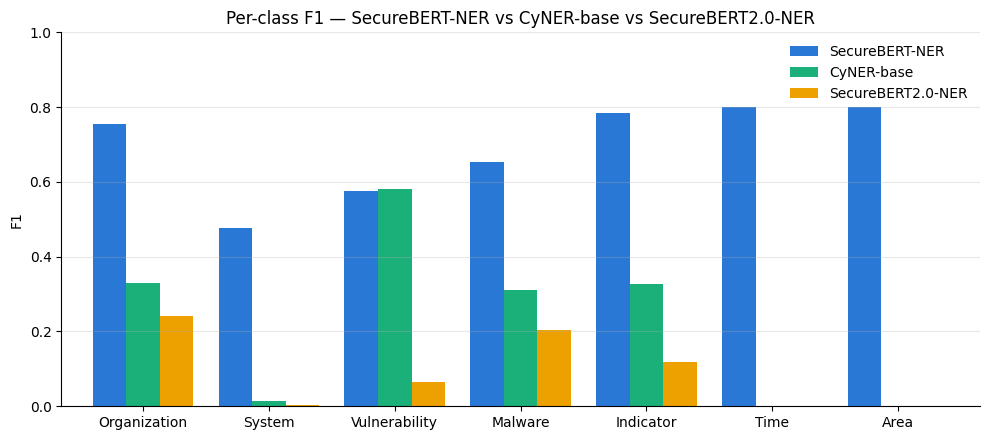

In [ ]:
MODEL_COLORS = {"SecureBERT-NER": "#2a78d6", "CyNER-base": "#1baf7a", "SecureBERT2.0-NER": "#eda100"}
FIG_PATH = RESULTS_DIR / "per_class_f1.png"

if not per_class_df.empty:
    piv = per_class_df.pivot(index="class", columns="model", values="f1").reindex(COMMON_CLASSES)
    order = [m for m in ["SecureBERT-NER", "CyNER-base", "SecureBERT2.0-NER"] if m in piv.columns]
    piv = piv[order]
    ax = piv.plot(kind="bar", figsize=(10, 4.5), rot=0, width=0.8,
                  color=[MODEL_COLORS.get(m, "#888888") for m in order])
    ax.set_ylabel("F1"); ax.set_xlabel(""); ax.set_ylim(0, 1)
    ax.set_title("Per-class F1 — SecureBERT-NER vs CyNER-base vs SecureBERT2.0-NER")
    ax.legend(title="", frameon=False)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
    fig = ax.get_figure(); fig.tight_layout()
    fig.savefig(FIG_PATH, dpi=150, bbox_inches="tight")
    print("Saved chart ->", FIG_PATH)
    plt.show()

## 10. Save results

In [ ]:
out = RESULTS_DIR / "benchmark_results.json"
payload = {
    "subset_size": len(subset),
    "seed": RANDOM_SEED,
    "models": results,                        # overall + per-class (seqeval strict)
    "shared_class": shared_df.to_dict("records"),
    "schemes": scheme_df.to_dict("records"),  # strict / exact / partial / type
    "footprint": foot,
}
with open(out, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)
print("Saved", out.resolve())

Saved /content/drive/MyDrive/NERF/benchmark/results/benchmark_results.json


## 11. Download — figures + comparison tables

Writes every summary table to CSV alongside the chart PNG and results JSON, bundles them into a single zip, and (in Colab) downloads it.

In [ ]:
overall_df.to_csv(RESULTS_DIR / "overall_metrics.csv", index=False)
per_class_df.to_csv(RESULTS_DIR / "per_class_metrics.csv", index=False)
shared_df.to_csv(RESULTS_DIR / "shared_metrics.csv", index=False)
scheme_df.to_csv(RESULTS_DIR / "scheme_metrics.csv", index=False)
foot_df.to_csv(RESULTS_DIR / "footprint.csv", index=False)

print("Artifacts in", RESULTS_DIR, ":")
for p in sorted(RESULTS_DIR.glob("*")):
    print("  ", p.name)

bundle_base = str((Path("/content") if IN_COLAB else RESULTS_DIR.parent) / "nerf_benchmark_summary")
zip_path = shutil.make_archive(bundle_base, "zip", RESULTS_DIR)
print("\nBundle ->", zip_path)

if IN_COLAB:
    from google.colab import files
    files.download(zip_path)
else:
    print("Local run: bundle saved at the path above.")

Artifacts in /content/drive/MyDrive/NERF/benchmark/results :
   benchmark_results.json
   footprint.csv
   overall_metrics.csv
   per_class_f1.png
   per_class_metrics.csv
   scheme_metrics.csv
   shared_metrics.csv

Bundle -> /content/nerf_benchmark_summary.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. Model selection & output analysis

**Models:** SecureBERT-NER (RoBERTa, APTNER 21-tag taxonomy), CyNER-base (XLM-RoBERTa, 5 classes), SecureBERT2.0-NER (ModernBERT, 5 classes). CyNER-large skipped — weights not public (see the note at the top).

**Evaluation setup:** full DNRTI **test** split — **662 sentences** scored (of 664; 2 had no entities and were dropped), `seed = 42`, `SUBSET_SIZE = None`. Gold has 7 common classes; the two 5-class models cannot produce Time/Area.

### Full summary table (per model)

| Model | P | R | **F1 micro** (7-cls) | **F1 macro** (7-cls) | F1 micro (shared-5) | strict | exact | partial | type | Params (M) | Latency (ms) |
|---|---|---|---|---|---|---|---|---|---|---|---|
| **SecureBERT-NER** | 0.703 | 0.696 | **0.700** | **0.692** | **0.678** | 0.700 | 0.750 | 0.798 | 0.759 | 124 | 122 |
| CyNER-base | 0.380 | 0.204 | 0.265 | 0.224 | 0.301 | 0.265 | 0.442 | 0.502 | 0.322 | 277 | 135 |
| SecureBERT2.0-NER | 0.124 | 0.170 | 0.144 | 0.090 | 0.155 | 0.144 | 0.268 | 0.389 | 0.292 | 150 | 157 |

_Scored on 662 DNRTI test sentences. `strict` F1 equals the 7-class micro-F1 (seqeval's default is the strict scheme). Latency = mean ms/sentence on Colab CPU._

### Micro-F1 vs Macro-F1 — what the two numbers mean
- **Micro-F1** pools **every entity across all classes** into one global precision/recall, then computes F1. It is dominated by the **frequent** classes (Organization has 782 gold spans, System 250, …), so it answers *"how well does the model do on a typical entity?"*
- **Macro-F1** computes F1 **separately for each class**, then averages them **with equal weight** — so a rare class (Vulnerability, 131 spans) counts as much as a common one. It answers *"how well does the model do across **all** classes, including the rare ones?"*
- **Reading the gap:** macro **much lower** than micro ⇒ the model is carried by frequent classes and weak on rare ones. Here SecureBERT-NER is 0.700 (micro) ≈ 0.692 (macro) — **consistent across classes**, a healthy sign; SecureBERT2.0 is 0.144 vs 0.090 — weak even on typical entities and weaker still on rare ones. (`f1_weighted`, in the metrics table above, sits in between: per-class F1 averaged but weighted by support.)

### Headline
**SecureBERT-NER wins decisively** — best on every metric, every class, and every matching scheme, while also being the **smallest** and **fastest** model.

### The weird result — SecureBERT2.0-NER collapses
The **newest** model (ModernBERT, advertised ~0.945 F1 on its *own* benchmark) is by far the **worst** here — F1 **0.14**, below even CyNER. The cause is **catastrophic over-prediction**: precision just **12%**, with huge false-positive counts (**781** spurious Indicators, **660** spurious Malware, 436 Organization, 363 System). The smoke test shows the behaviour directly — it tags `the` as Malware, `analysts` as Organization, `traffic` and trailing punctuation as Indicator, and labels the whole CVE as *Indicator* (wrong type). It labels almost everything.

**Most likely causes:** (1) DNRTI is far **out-of-distribution** for it; (2) sensitivity to our **space-joined reconstruction** — DNRTI is pre-tokenised, so punctuation ends up space-separated (`CVE - 2021 - 44228 .`, `185 . 220 . 101 . 47`), which ModernBERT appears to handle far worse than the RoBERTa/XLM-R models. Its 0.945 headline is on its in-distribution test set.

**Takeaway:** newest ≠ best on *your* data — a reminder to benchmark on your actual distribution rather than trusting a model card.

### Failure-mode contrast
- **SecureBERT-NER** — balanced (P ≈ R ≈ 0.70).
- **CyNER-base** — precision (0.38) > recall (0.20): **conservative**, under-tags, *misses* entities (FN-heavy).
- **SecureBERT2.0-NER** — precision (0.12) < recall (0.17): **trigger-happy**, over-tags, *invents* entities (FP-heavy).

### Fair shared-class view (5 classes both taxonomies cover)
Even on the level field (dropping Time/Area, which the 5-class models can't produce), SecureBERT-NER leads by **~2.2×** over CyNER (0.678 vs 0.301) and **~4×** over SecureBERT2.0 (vs 0.155) — so the gap is **real**, not just a coverage artefact.

### Matching schemes — ranking is robust
The 5-class models jump sharply from **strict → partial** (CyNER 0.27 → 0.50), i.e. they often find the right *region* but with wrong *boundaries/type* (fragmentation). SecureBERT-NER's small strict→partial gap (0.70 → 0.80) means its boundaries are already tight. **Under every scheme, the order is SecureBERT-NER > CyNER-base > SecureBERT2.0-NER** — it never changes.

### Per-class highlights
- **SecureBERT-NER wins every class.** It's the only model that produces **Time** (0.80) and **Area** (0.80). Strong on Indicator (0.78) and Organization (0.75).
- **Vulnerability** is the sole near-tie: SecureBERT-NER 0.576 vs CyNER **0.582** (CyNER a hair ahead) — CyNER's best-aligned class.
- **System** is the hardest class for everyone (SecureBERT 0.48) — DNRTI's `OffAct`/`Way` is a fuzzy category and the taxonomies disagree on it.

### Footprint & latency
- **Params:** SecureBERT-NER **124M** (smallest) · SecureBERT2.0-NER 150M · CyNER-base 277M.
- **Latency (mean):** SecureBERT-NER **122 ms** < CyNER 135 ms < SecureBERT2.0 157 ms — fastest, too.
- Two measurement caveats: `peak_rss_MB` is identical (~2530) because it's **process-wide** with all three models resident — not a per-model signal (use `params_M`/`est_fp32_MB`); and `disk_MB` is unreliable (SecureBERT's HF repo ships duplicate `.bin` + `.safetensors`, inflating its number).

### Domain-alignment caveat (honest framing)
SecureBERT-NER was fine-tuned on **APTNER**, whose tags nearly match DNRTI's, so DNRTI is close to **in-distribution** for it; the two 5-class models were trained on different data/taxonomies, making DNRTI **out-of-distribution**. This benchmark therefore partly measures **domain/label alignment** — which is exactly why the best-aligned model is the right choice for a DNRTI-like product. It also means CyNER/SecureBERT2.0 aren't "bad models" in general — they're **mismatched** to this benchmark.

### Business framing
In threat intel a **missed IOC (false negative)** is costlier than a false alarm, so we weight **recall** — where SecureBERT-NER's lead is largest (0.696 vs 0.204 vs 0.170).

### Decision
**Ship SecureBERT-NER.** It is the most accurate (by 2–5×), the smallest, the fastest, the only model covering Time/Area, the best aligned to DNRTI-style data, and cleanly deployable on-prem (a standard HF model — no package or toolchain pain). CyNER-base is a distant second; SecureBERT2.0-NER, despite being the newest, is unusable on this data without domain fine-tuning.